# Traffic congestion classifier

**Goal:** Classify highway video clips as **light**, **medium**, or **heavy** traffic.

**Data:** 254 labelled clips from one Seattle highway camera over two days. Resolution: 320 x 240 at 10 fps.

**Summary:** I fine-tune ResNet-18 on three-frame stacks, evaluate on folds that keep each recording run together, and export the final model to ONNX with preprocessing metadata.

## 0. Check the Colab runtime

Select a GPU runtime before training.


In [1]:
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch {torch.__version__} · {DEVICE}')
if DEVICE == 'cuda':
    print(torch.cuda.get_device_name(0))
else:
    print('No GPU — set Runtime > Change runtime type > T4 GPU')

torch 2.11.0+cu128 · cuda
Tesla T4


## 1. Load data and define evaluation

Install dependencies and download the traffic dataset from Kaggle.


In [2]:
%pip install -q kagglehub opencv-python-headless onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 20.2 MB/s eta 0:00:00


In [3]:
import pathlib, shutil
import kagglehub

# Copy the Kaggle cache into a folder visible in Colab's file browser.
HERE = pathlib.Path('/content')                  # Colab's own working folder
WORKSPACE = HERE if HERE.exists() else pathlib.Path.cwd()
DATA = WORKSPACE / 'traffic-data'
if not DATA.exists():
    cache = pathlib.Path(
        kagglehub.dataset_download('aryashah2k/highway-traffic-videos-dataset'))
    root = next(cache.rglob('info.txt')).parent   # the archive nests a level or two
    shutil.copytree(root, DATA)
VIDEO = DATA / 'video'

print(DATA.resolve())
print(len(list(VIDEO.glob('*.avi'))), 'clips')

Using Colab cache for faster access to the 'highway-traffic-videos-dataset' dataset.
/content/traffic-data
254 clips


### 1.1. Read metadata

`info.txt` holds the clip metadata and labels. Group consecutive serial numbers from the same day into recording runs.

In [4]:
import pandas as pd

CLASSES = ['light', 'medium', 'heavy']      # ordered light -> heavy, not a-z

COLUMNS = ['filename', 'date', 'timestamp', 'direction', 'day_night', 'weather',
           'start_frame', 'n_frames', 'label', 'notes']

# Tab-separated, '#' header skipped.
info = pd.read_csv(DATA / 'info.txt', sep='\t', comment='#', names=COLUMNS,
                   encoding_errors='replace').set_index('filename')

# Group consecutive clip serials from the same day into recording runs.
info['serial'] = info.index.str.extract(r'x(\d+)$')[0].astype(int).to_numpy()
ordered = info.sort_values(['date', 'serial'])
starts_a_run = (ordered['serial'].diff() != 1) | (ordered['date'].diff() != 0)
info['run'] = starts_a_run.cumsum().reindex(info.index)

CLIPS, y = info.index.to_numpy(), info['label'].to_numpy()

assert len(info) == 254

print('clips  ', len(info), info['label'].value_counts().to_dict())
print('runs   ', info['run'].nunique())

clips   254 {'light': 165, 'medium': 45, 'heavy': 44}
runs    14


### 1.2. Choose metrics and split

The class counts are 165 / 45 / 44. Predicting only the majority class gives about 65% accuracy, so report **macro-F1** and a confusion matrix alongside accuracy.

Adjacent clips can show nearly the same scene, so evaluate with `StratifiedGroupKFold`, which keeps each recording run in one fold. Use the same evaluation helper for the baselines and CNN.

In [5]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

SPLIT = 'grouped by recording'

# Keep each recording run together while balancing class proportions.
CV = list(StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=0)
          .split(CLIPS, y, info['run']))

def evaluate(estimator, features, name):
    """Cross-validate one estimator over the grouped folds."""
    predicted = cross_val_predict(estimator, features, y, cv=CV)
    return {'name': name, 'y_true': y, 'y_pred': predicted,
            'accuracy': accuracy_score(y, predicted),
            'macro_f1': f1_score(y, predicted, labels=CLASSES,
                                 average='macro', zero_division=0)}

def report(result):
    print(result['name'])
    print(classification_report(result['y_true'], result['y_pred'],
                                labels=CLASSES, zero_division=0, digits=3))
    matrix = confusion_matrix(result['y_true'], result['y_pred'], labels=CLASSES)
    print(pd.DataFrame(matrix, index=[f'true {c}' for c in CLASSES],
                       columns=[f'pred {c}' for c in CLASSES]), '\n')

### 1.3. Baselines

Score two reference models on the grouped folds: a **majority-class baseline** and a **nearest-recording baseline** that uses only the day and clip serial number, without reading any pixels. The CNN has to beat both.

In [6]:
class NearestRecording(BaseEstimator, ClassifierMixin):
    """Copy the label of the nearest clip in recording order. Reads not one pixel."""

    def fit(self, when, labels):
        self.when_, self.labels_ = np.asarray(when), np.asarray(labels)
        return self

    def predict(self, when):
        when = np.asarray(when)
        apart = np.abs(when[:, None, 1] - self.when_[None, :, 1])
        apart = apart + 1e6 * (when[:, None, 0] != self.when_[None, :, 0])   # other day
        return self.labels_[apart.argmin(axis=1)]

WHEN = info[['date', 'serial']].to_numpy()
NOTHING = np.zeros((len(y), 1))          # the majority baseline is handed no features

BASELINES = [evaluate(DummyClassifier(strategy='most_frequent'), NOTHING, 'majority class'),
             evaluate(NearestRecording(), WHEN, 'nearest recording (no pixels)')]

print(f"{'model':<32s}{'accuracy':>9s}{'macro-F1':>10s}")
for r in BASELINES:
    print(f"{r['name']:<32s}{r['accuracy']:>9.1%}{r['macro_f1']:>10.3f}")

model                            accuracy  macro-F1
majority class                      65.0%     0.263
nearest recording (no pixels)       71.3%     0.584


**Read the baseline table:** The majority baseline is the minimum reference; the nearest-recording baseline is the score available without reading any image.

## 2. Prepare three-frame samples

Crop to the southbound roadway at `x >= 112`, skip the corrupted first frame, and resize to 160 x 160 RGB. Keep frames **2, 12, 22, 32, 42**, one second apart.

```text
Window 1:  2, 12, 22
Window 2: 12, 22, 32
Window 3: 22, 32, 42
```

Draw one window per clip during training. At inference, average logits from all three windows to produce one clip label.

The earlier frame-gap analysis found more class separation at one second than at adjacent frames. Three frames retain temporal information while leaving three overlapping windows; this is a design choice, not a measured optimum.


In [7]:
import cv2

CROP_X = 112        # roadway starts here; northbound ends near x=60
FIRST_FRAME = 2     # frame 1 is corrupted in every clip
N_FRAMES = 3        # three frames per sample leave three overlapping windows
GAP = 10            # 1.0 s at 10 fps
SIZE = 160          # the crop is only 208x240, so upscaling past this adds nothing

# Keep five grid frames; the shortest clip has 43 frames.
N_KEEP = 5
GRID = [FIRST_FRAME + i * GAP for i in range(N_KEEP)]        # frames 2, 12, 22, 32, 42
N_STARTS = N_KEEP - N_FRAMES + 1                             # 3 distinct windows

def clip_frames(name):
    """Decode one clip and keep only the grid frames: (N_KEEP, SIZE, SIZE, 3) RGB."""
    wanted, kept, number = set(GRID), {}, 0
    capture = cv2.VideoCapture(str(VIDEO / f'{name}.avi'))
    while len(kept) < N_KEEP:
        ok, frame = capture.read()
        if not ok:
            break
        number += 1
        if number in wanted:
            # Convert OpenCV's BGR frames to RGB for the model and plots.
            kept[number] = cv2.cvtColor(
                cv2.resize(frame[:, CROP_X:], (SIZE, SIZE), interpolation=cv2.INTER_AREA),
                cv2.COLOR_BGR2RGB)
    capture.release()
    last = max(kept)                 # a clip that ends early repeats its last frame
    return np.stack([kept.get(f, kept[last]) for f in GRID])

In [8]:
# Decode all 254 clips, in info.txt's order so the rows line up with `y`.
X = np.zeros((len(CLIPS), N_KEEP, SIZE, SIZE, 3), np.uint8)
for i, name in enumerate(CLIPS):
    X[i] = clip_frames(name)
    if (i + 1) % 50 == 0 or i + 1 == len(CLIPS):
        print(f'decoding {i + 1}/{len(CLIPS)}', end='\r')

print(f'{X.shape}  {X.nbytes / 1e6:.0f} MB   {N_KEEP} frames per clip, '
      f'{GAP / 10} s apart, {N_STARTS} windows')

(254, 5, 160, 160, 3)  98 MB   5 frames per clip, 1.0 s apart, 3 windows


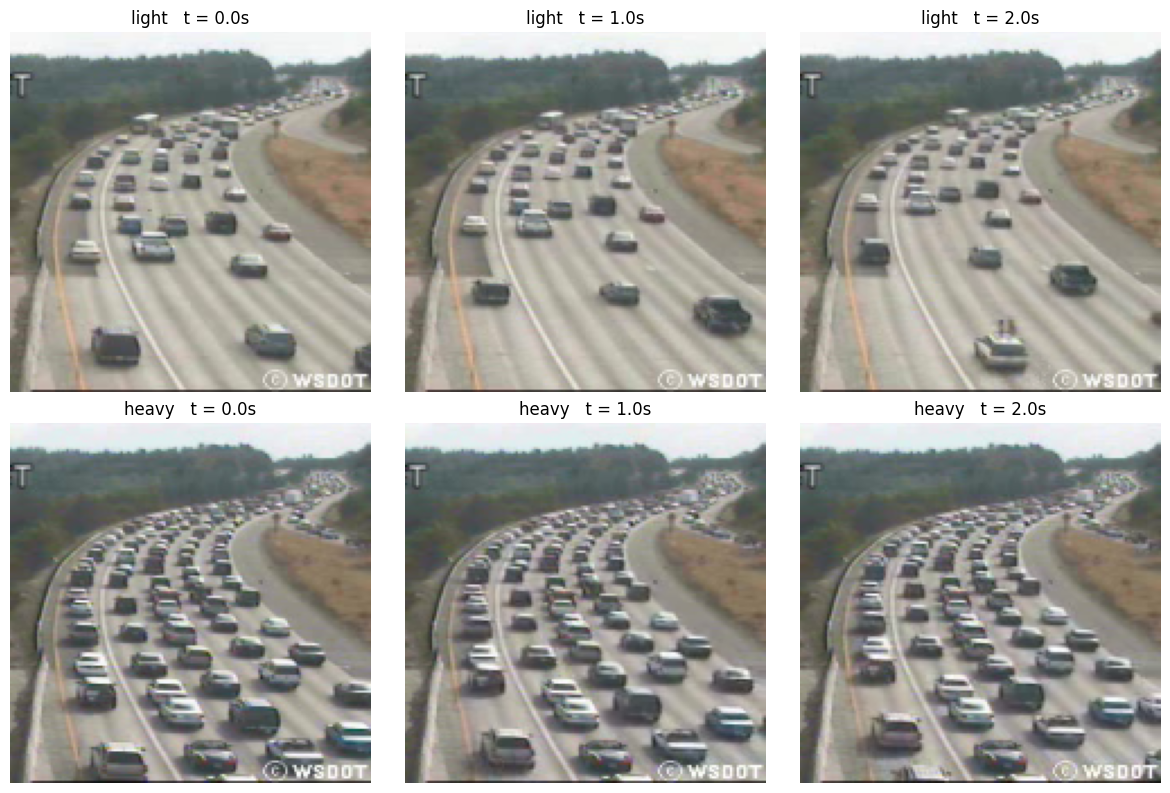

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, N_FRAMES, figsize=(4 * N_FRAMES, 8))
for row, want in enumerate(['light', 'heavy']):
    i = int(np.flatnonzero(y == want)[0])
    for col in range(N_FRAMES):
        axes[row, col].imshow(X[i, col])
        axes[row, col].set_title(f'{want}   t = {col * GAP / 10:.1f}s')
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

## 3. Apply consistent augmentation

Apply the same random transform to all frames in a stack to preserve temporal differences.

| Transform | Setting | Reason |
|---|---|---|
| Brightness and contrast | 80% probability; clamp factors using measured image statistics | Model exposure changes while limiting loss of detail |
| Translation | 80% probability; up to 4 pixels | Represent the camera shift between days |
| Grain | 50% probability; shared noise field, sigma = 3 | Add image noise without separate noise in each frame |
| Flip, rotation, random resized crop, erasing | Off | Retain road layout and vehicle-size cues |

Use edge padding for shifts. Shared grain avoids adding independent noise to frame differences, although clipping can still affect them. Contrast changes can reduce the difference magnitude.

The brightness and contrast bands come from all 254 clips. The grouped evaluation therefore holds out training clips but does not provide a fully independent estimate of these preprocessing choices. Apply augmentation only during training.


In [10]:
SHIFT_PX = 4        # about 4 px after resizing the measured camera shift

# Image-statistic bands measured across all 254 clips; see section 3.
CONTRAST_BAND = (32.6, 57.1)
BRIGHTNESS_BAND = (106.0, 198.0)

def augment(stack, rng):
    """One draw per stack, applied identically to every frame in it.

    Each transform fires with a probability rather than every time. Test samples get
    none of this, so a network that only ever saw augmented input would be scored on
    a distribution it never trained on.
    """
    out = stack.astype(np.float32)

    if rng.random() < 0.8:
        # Bound the factors using the clip's current brightness and contrast.
        mean, spread = out.mean(), out.std()
        contrast = np.clip(1 + rng.uniform(-0.20, 0.20),
                           CONTRAST_BAND[0] / spread, CONTRAST_BAND[1] / spread)
        brightness = np.clip(1 + rng.uniform(-0.15, 0.15),
                             BRIGHTNESS_BAND[0] / mean, BRIGHTNESS_BAND[1] / mean)
        out = (out - mean) * contrast + mean * brightness

    if rng.random() < 0.8:
        # Pad with edge pixels, then crop to translate without wraparound.
        dy, dx = rng.integers(-SHIFT_PX, SHIFT_PX + 1, size=2)
        padded = np.pad(out, ((0, 0), (SHIFT_PX,) * 2, (SHIFT_PX,) * 2, (0, 0)),
                        mode='edge')
        out = padded[:, SHIFT_PX + dy:SHIFT_PX + dy + SIZE,
                        SHIFT_PX + dx:SHIFT_PX + dx + SIZE]

    if rng.random() < 0.5:
        # Share one noise field across frames and colour channels.
        out = out + rng.normal(0, 3.0, out.shape[1:-1])[None, ..., None]

    return np.clip(out, 0, 255).astype(np.uint8)

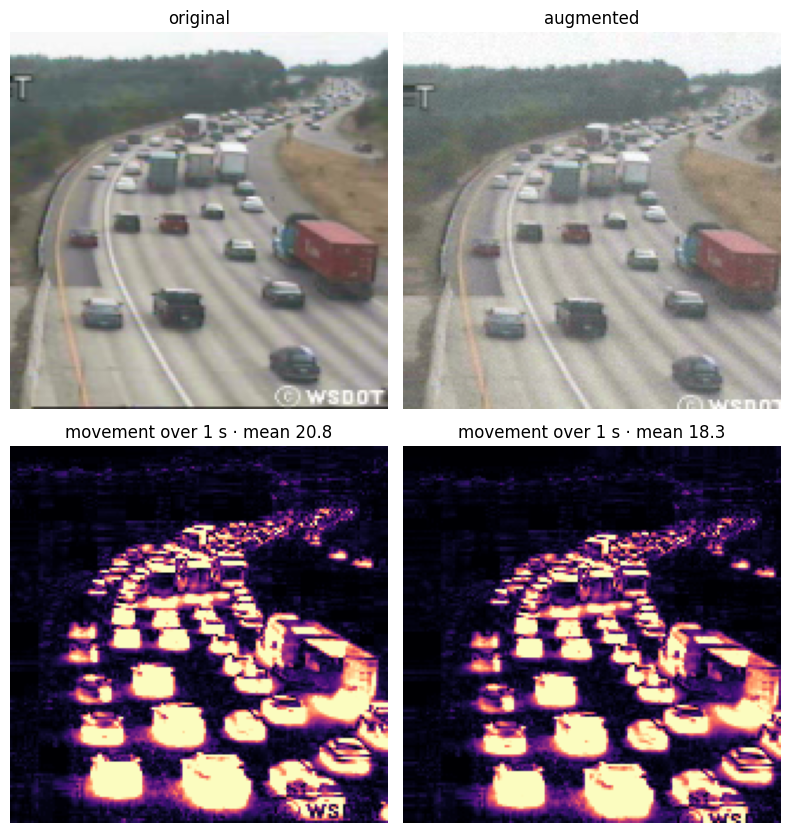

In [11]:
# Compare frames and absolute differences to inspect augmentation's effect.
# Lower contrast can reduce the difference magnitude.
shown = {'original': X[0], 'augmented': augment(X[0], np.random.default_rng(3))}
fig, axes = plt.subplots(2, 2, figsize=(8, 8.5))
for col, (title, stack) in enumerate(shown.items()):
    moved = np.abs(stack[0].astype(np.int16) - stack[1]).mean(axis=2)
    axes[0, col].imshow(stack[0]);  axes[0, col].set_title(title)
    axes[1, col].imshow(moved, cmap='magma', vmin=0, vmax=60)
    axes[1, col].set_title(f'movement over 1 s · mean {moved.mean():.1f}')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Build the model and dataset

Stack three RGB frames into **9 input channels**. Widen ResNet-18's first convolution by repeating its pretrained weights and dividing by three to retain the response scale for repeated inputs.

Replace the final layer with three outputs and apply ImageNet normalization per frame. In the dataset, seed each sample's random generator from PyTorch so workers can draw new windows and augmentations.


In [12]:
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models

MEAN = torch.tensor([0.485, 0.456, 0.406] * N_FRAMES).view(-1, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225] * N_FRAMES).view(-1, 1, 1)

def build_model():
    model = models.resnet18(weights='DEFAULT')
    old, wide_in = model.conv1, N_FRAMES * 3
    wide = nn.Conv2d(wide_in, old.out_channels, old.kernel_size, old.stride,
                     old.padding, bias=False)
    with torch.no_grad():
        wide.weight.copy_(old.weight.repeat(1, N_FRAMES, 1, 1) / N_FRAMES)
    model.conv1 = wide
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model

In [13]:
def to_tensor(stack):
    """(N_FRAMES, SIZE, SIZE, 3) uint8 RGB -> (N_FRAMES*3, SIZE, SIZE) normalised."""
    t = torch.from_numpy(np.ascontiguousarray(stack))
    t = t.permute(0, 3, 1, 2).reshape(-1, SIZE, SIZE).float() / 255
    return (t - MEAN) / STD

class Clips(Dataset):
    """One item per clip. Which window it shows is redrawn on every access."""

    def __init__(self, frames, labels):
        self.frames = frames
        self.targets = np.array([CLASSES.index(l) for l in labels])

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, i):
        # Draw a PyTorch seed for each sample to avoid copying a stored RNG to workers.
        rng = np.random.default_rng(torch.randint(1 << 31, ()).item())
        start = rng.integers(0, N_STARTS)
        window = self.frames[i, start:start + N_FRAMES]
        return to_tensor(augment(window, rng)), int(self.targets[i])

## 5. Train and evaluate

Wrap the CNN in sklearn's `fit` / `predict` interface to use the same cross-validation helper as the baselines. Each fold keeps recording runs together.

Train for **60 epochs** with batch size **32** and learning rate **3e-4**. Use AdamW, cosine learning-rate decay, and class-weighted cross-entropy with label smoothing.

During training, draw one three-frame window per clip. During prediction, average logits across all three windows without augmentation.


In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Each epoch samples each training clip once; fold sizes determine batch counts.
EPOCHS, BATCH, LR = 60, 32, 3e-4

def train(frames, labels):
    torch.manual_seed(0)
    loader = DataLoader(Clips(frames, labels), batch_size=BATCH, shuffle=True,
                        num_workers=2)
    model = build_model().to(DEVICE)

    weights = compute_class_weight('balanced', classes=np.array(CLASSES), y=labels)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05,
                                  weight=torch.tensor(weights, dtype=torch.float32,
                                                      device=DEVICE))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    model.train()
    for epoch in range(EPOCHS):
        total = 0.0
        for xb, yb in loader:
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE))
            loss.backward()
            opt.step()
            total += loss.item() * len(yb)
        sched.step()
        print(f'    epoch {epoch + 1}/{EPOCHS}  loss {total / len(labels):.3f}', end='\r')
    return model

In [15]:
class CongestionCNN(BaseEstimator, ClassifierMixin):
    """The torch model behind sklearn's interface, so it cross-validates
    like everything else here."""

    def fit(self, frames, labels):
        self.model_ = train(frames, labels)
        return self

    @torch.no_grad()
    def predict(self, frames):
        """Score every window of a clip and average the logits before deciding."""
        self.model_.eval()
        chosen = []
        for clip in frames:
            windows = torch.stack([to_tensor(clip[s:s + N_FRAMES])
                                   for s in range(N_STARTS)])
            logits = self.model_(windows.to(DEVICE)).cpu().numpy().mean(axis=0)
            chosen.append(CLASSES[int(logits.argmax())])
        return np.array(chosen)

### 5.1. Evaluate on grouped folds

Initialize a fresh model from pretrained weights for each fold. Report the CNN's accuracy, macro-F1, and confusion matrix.

In [16]:
FINETUNED = evaluate(CongestionCNN(), X, 'fine-tuned resnet18')
print()
report(FINETUNED)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


    epoch 60/60  loss 0.221
fine-tuned resnet18
              precision    recall  f1-score   support

       light      0.988     0.994     0.991       165
      medium      0.822     0.822     0.822        45
       heavy      0.860     0.841     0.851        44

    accuracy                          0.937       254
   macro avg      0.890     0.886     0.888       254
weighted avg      0.937     0.937     0.937       254

             pred light  pred medium  pred heavy
true light          164            1           0
true medium           2           37           6
true heavy            0            7          37 



## 6. Compare results

Compare the CNN with both baselines using accuracy and macro-F1.

In [17]:
rows = [{'model': r['name'], 'accuracy': f"{r['accuracy']:.1%}",
         'macro-F1': f"{r['macro_f1']:.3f}"} for r in [*BASELINES, FINETUNED]]
print(pd.DataFrame(rows).set_index('model'), '\n')

print(f"Fine-tuned resnet18 on grouped folds: "
      f"{FINETUNED['accuracy']:.1%} accuracy, {FINETUNED['macro_f1']:.3f} macro-F1.")

                              accuracy macro-F1
model                                          
majority class                   65.0%    0.263
nearest recording (no pixels)    71.3%    0.584
fine-tuned resnet18              93.7%    0.888 

Fine-tuned resnet18 on grouped folds: 93.7% accuracy, 0.888 macro-F1.


## 7. Train the final model and export

After cross-validation, fit the final model on all 254 clips. Use held-out cross-validation results to describe performance; training on all clips does not create a new test score.

Export `congestion_cnn.onnx` for ONNX Runtime and `eval_finetune.json` for evaluation results. Store the crop, frame spacing, class order, and normalization recipe as ONNX metadata; the app must apply that recipe.

The existing export check compares PyTorch and ONNX outputs and checks the metadata. Download both files into the app's `models/` folder.



In [18]:
import json
import onnx
import onnxruntime as ort

MODELS = pathlib.Path('models')      # a real folder, visible in the file browser
MODELS.mkdir(exist_ok=True)
MODEL_PATH = MODELS / 'congestion_cnn.onnx'

PREPROCESSING = {
    'classes': CLASSES, 'crop_x': CROP_X, 'first_frame': FIRST_FRAME, 'gap': GAP,
    'n_frames': N_FRAMES, 'size': SIZE, 'colour': 'RGB',
    'n_keep': N_KEEP, 'test_starts': [s * GAP for s in range(N_STARTS)],
    'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225],
}

# Exported from the CPU, so the file is device-neutral.
final = CongestionCNN().fit(X, y).model_.eval().cpu()
example = torch.zeros(1, N_FRAMES * 3, SIZE, SIZE)

# Keep the batch axis dynamic to score multiple windows per clip.
torch.onnx.export(final, example, str(MODEL_PATH),
                  input_names=['stacks'], output_names=['logits'],
                  dynamic_axes={'stacks': {0: 'n'}, 'logits': {0: 'n'}})

graph = onnx.load(str(MODEL_PATH))
graph.metadata_props.append(
    onnx.StringStringEntryProto(key='preprocessing', value=json.dumps(PREPROCESSING)))
onnx.save(graph, str(MODEL_PATH))

/tmp/ipykernel_1516/3115738595.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(final, example, str(MODEL_PATH),


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


In [19]:
# Compare ONNX and PyTorch outputs with a different batch size; check metadata.
batch = torch.randn(5, N_FRAMES * 3, SIZE, SIZE)
session = ort.InferenceSession(str(MODEL_PATH), providers=['CPUExecutionProvider'])
exported = session.run(None, {'stacks': batch.numpy()})[0]
with torch.no_grad():
    trained = final(batch).numpy()

carried = json.loads(session.get_modelmeta().custom_metadata_map['preprocessing'])
assert np.allclose(trained, exported, atol=1e-4), np.abs(trained - exported).max()
assert carried == PREPROCESSING

(MODELS / 'eval_finetune.json').write_text(json.dumps({
    'results': [{'split': SPLIT, **{k: v for k, v in r.items()
                                    if k not in ('y_true', 'y_pred')}}
                for r in [*BASELINES, FINETUNED]],
    'headline': SPLIT,
    'confusion': {SPLIT: confusion_matrix(FINETUNED['y_true'], FINETUNED['y_pred'],
                                          labels=CLASSES).tolist()},
    'preprocessing': PREPROCESSING,        # a readable copy; the model holds the real one
    'training': {'arch': 'resnet18', 'epochs': EPOCHS, 'batch': BATCH, 'lr': LR},
}, indent=2))

print(f'{MODEL_PATH}  {MODEL_PATH.stat().st_size / 1e6:.0f} MB, '
      'carrying its own preprocessing')
print(f'agrees with the trained model to {np.abs(trained - exported).max():.2e}')
print(f'{MODELS / "eval_finetune.json"}  written')

models/congestion_cnn.onnx  45 MB, carrying its own preprocessing
agrees with the trained model to 6.71e-07
models/eval_finetune.json  written


In [20]:
from google.colab import files

files.download(str(MODEL_PATH))                    # -> models/ in the repo
files.download(str(MODELS / 'eval_finetune.json'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>